In [ ]:
#HW11.2. Obtain the deflection equation
l=3
a0=-l**4/384
a1=l**3/48
a2=-l**2/4
a3=l/6
a4=-1/24
print("The deflection equation is:")
print("y(x) = ",a0,"+",a1,"x^1 + ",a2,"x^2 + ",a3,"x^3 + ",a4,"x^4  ")

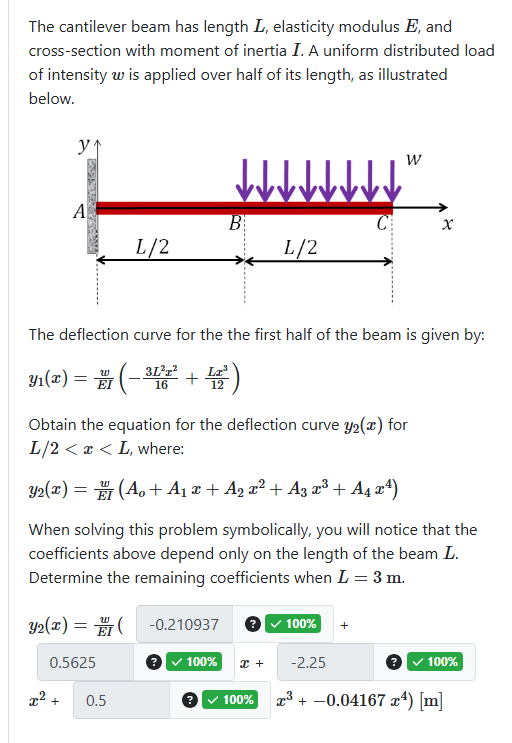

In [ ]:
#HW11.3. Obtain the deflection equation - two parts
from sympy import *

P = 9 # kN
M = 11 # kN.m
L = 6 # m
E = 227 # GPa
Iz = 0.000052 # m^4

p=P*1000 # N
m=M*1000 # N.m
e=E*1e9 # Pa
l=L # m

x = symbols('x')
y1 = 1/e/Iz*(0.5*(p*l-m)*x**2-p/6*x**3)
print(y1)

y2 = 1/e/Iz*((p/2*l**2-m*l)*x+(-1/6*p*l**3+1/2*m*l**2))
print(y2)

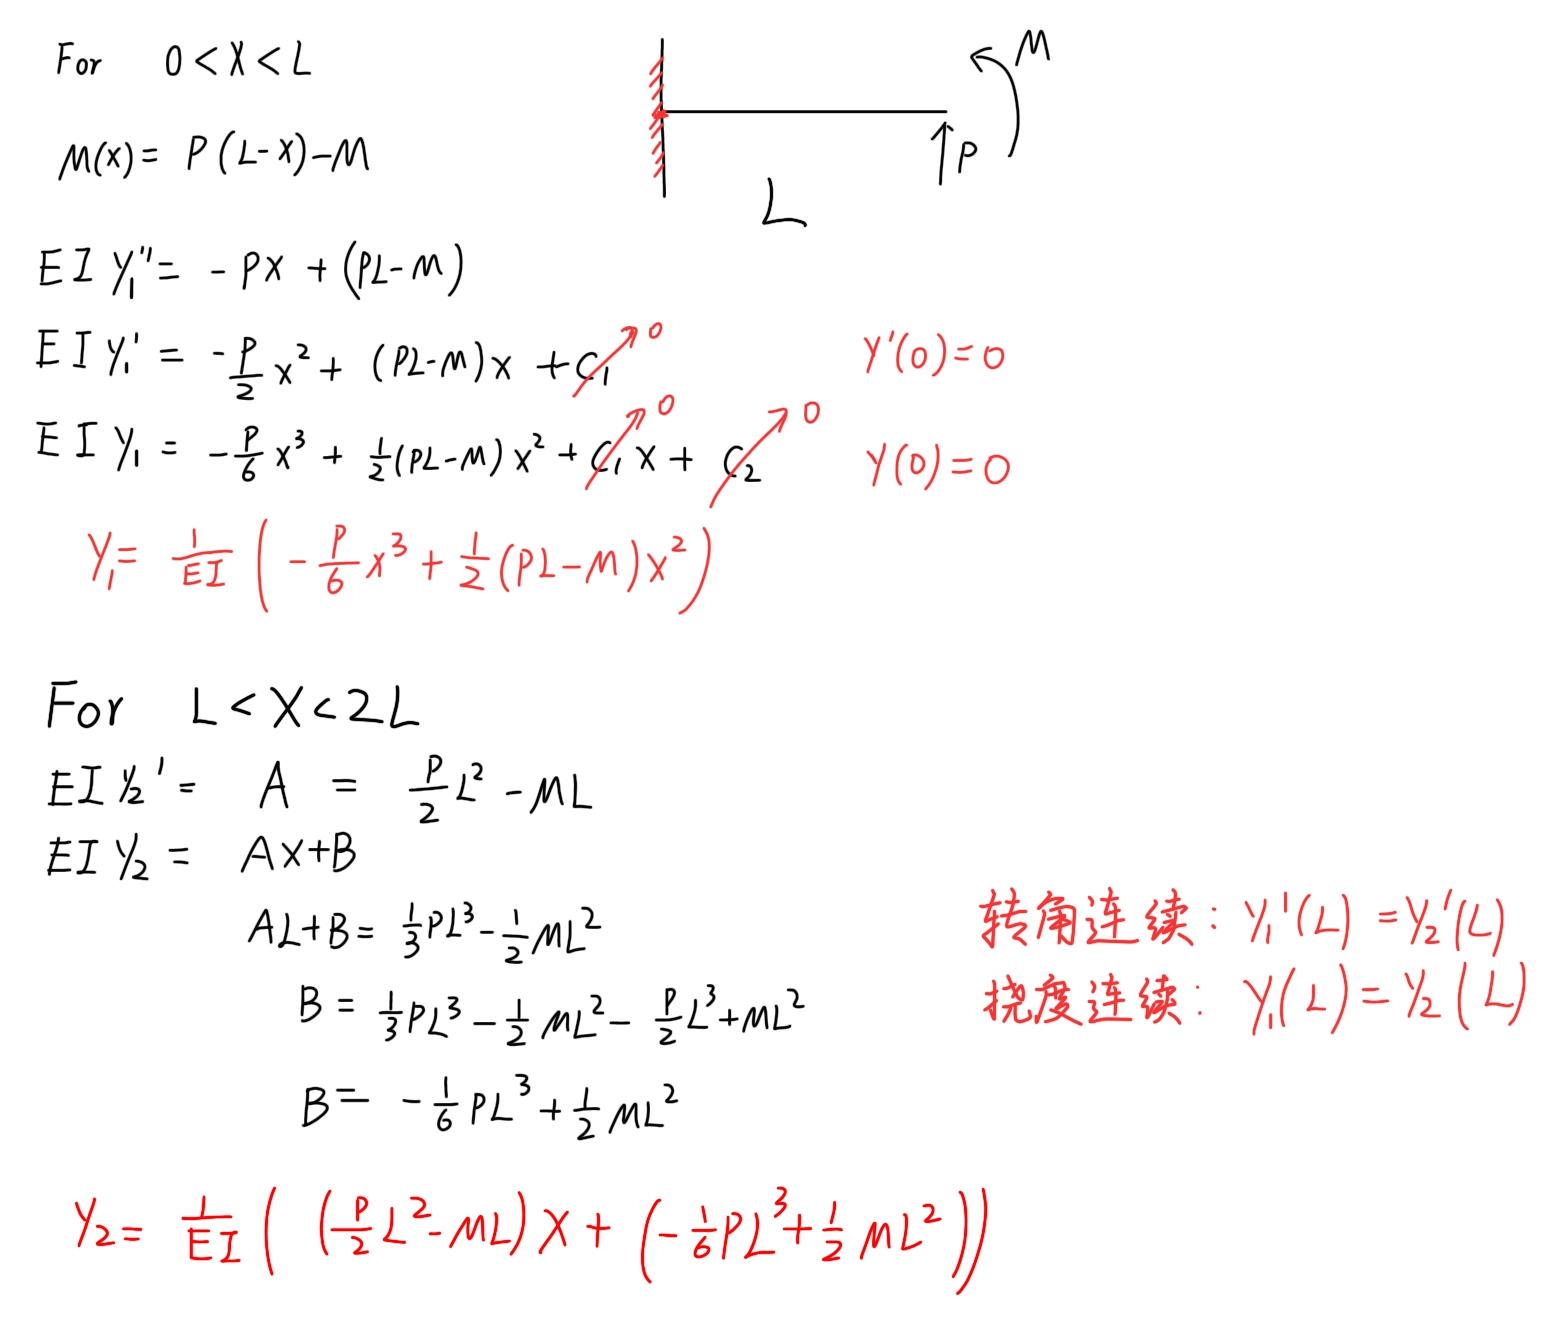

In [ ]:
#HW11.4. Cantilever with Rigid Post: Find Reaction Force
from sympy import *

M = 60 # kN.m
L = 1620 # mm
delta = 2 # mm
E = 146 # GPa
Iz = 162067500 # mm^4

m=M*1e3 # N.m
l=L*1e-3 # m
delta=delta*1e-3 # m
e=E*1e9 # Pa
Iz=Iz*1e-12 # m^4

t = symbols('t')
#查表可得中点的v
y_mid = -m*l**2/2/e/Iz
y1=-m*l/e/Iz*(2*l-l)+y_mid
y2=t*(2*l)**3/3/e/Iz


y= y1+y2
sol=solve(delta + y, t)
print(sol)
print("The reaction force is: ",sol[0]/1000," kN")

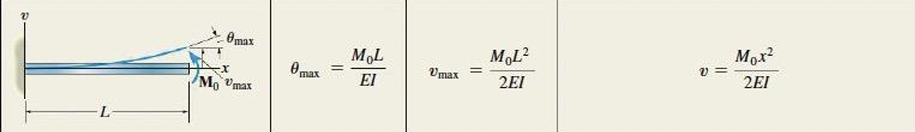
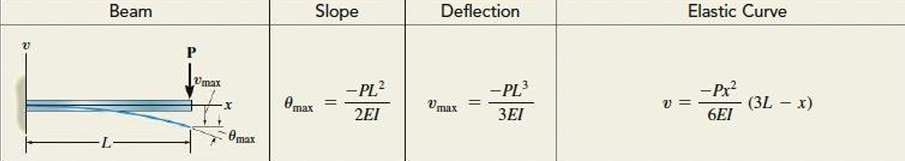

In [ ]:
#HW11.5. Obtain the deflection at the mid-point
from sympy import *

P = 6 # kN
E = 243 # GPa
A = 213 # mm^2
L = 5 # m
H = 3 # m
Iz = 55000000 # mm^4

p=P*1000 # N
e=E*1e9 # Pa
a=A*1e-6 # m^2
l=L # m
h=H # m
iz=Iz*1e-12 # m^4

fc=p/2
v1=-p*l/2*(3*l**2-4*(l/2)**2)/48/e/iz

delta_cd=fc*h/(e*a)  #拉杆轴向拉伸的伸长量
delta_b=delta_cd/2

print(abs(v1-delta_b)*1e3)


In [ ]:
#HW11.6. Obtain the tension in the cable
from sympy import *

L = 7 # m
H = 2 # m
E = 184 # GPa
Iz = 45000000 # mm^4
w = 8 # kN/m
A = 202 # mm^2

e=E*1e9 # Pa
a=A*1e-6 # m^2
l=L # m
h=H # m
iz=Iz*1e-12 # m^4
w=w*1e3

t = Symbol('t')
v1=-w*l**3/384/e/iz*(7*l)

v2=t*l**2/6/e/iz*(2*l)

sol=solve(v1+v2+t*h/e/a,t)  #正确的变形协调方程：v1 + v2 = -Δ （Δ = t*H/(e*a)）
print(sol[0]/1e3)

3.05061209672783


In [2]:
import math

# 1. 题目已知参数（单位已统一为国际单位）
L = 7.0        # 梁长度 m
H = 2.0        # 钢索长度 m
E = 184e9      # 弹性模量 Pa
Iz = 45e-6     # 截面惯性矩 m^4
w = 8000      # 均布荷载 N/m
A = 202e-6     # 钢索截面积 m^2

# 2. 计算均布荷载产生的 C 点向下挠度
a = L / 2
delta_load = (w * a**4) / (8 * E * Iz) + (w * a**3) / (6 * E * Iz) * (L - a)

# 3. 计算刚度项（分母）
denominator = (L**3) / (3 * E * Iz) + H / (E * A)

# 4. 求解钢索张力 T
T = delta_load / denominator

# 5. 输出结果（kN）
print(f"钢索张力 T = {T / 1000:.2f} kN")

钢索张力 T = 3.05 kN


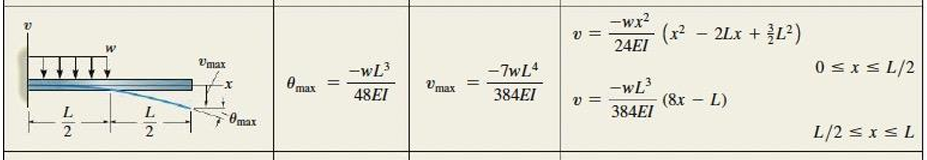
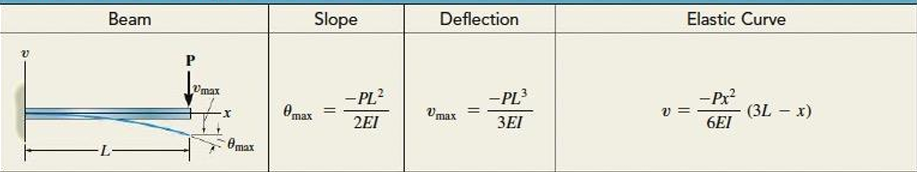

In [3]:
#HW11.7. Determine the slope and deflection at the free end
from sympy import *

P = 16 # kN
L = 8 # m
E = 215 # GPa
Iz = 0.000060 # m^4

p=P*1000 # N
e=E*1e9 # Pa
l=L # m
iz=Iz

w=p/l

vc1=-w*l**2/24/e/iz*(2*l**2)

vc2=p*l**2/48/e/iz*(5*l)
#print(vc1)
#print(vc2)
yc=vc1+vc2
print(-yc*1e3)

theta=-w*l**3/6/e/iz+p*l**2/8/e/iz
print(theta)

-13.229974160206721
-0.003307493540051677


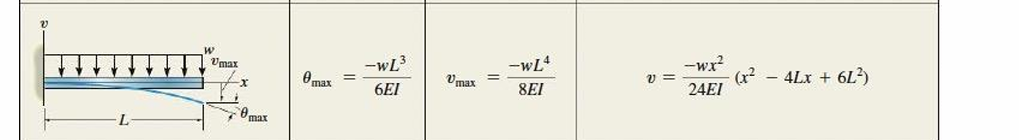
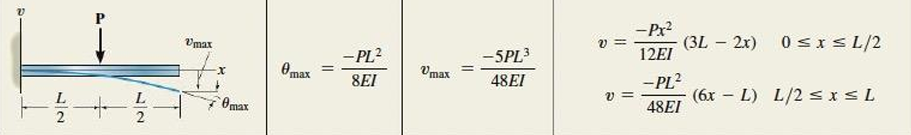

In [4]:
#HW11.8. Determine the slope and deflection at the free end
from sympy import *

w = 7 # kN/m
L = 6 # m
E = 229 # GPa
Iz = 0.000047 # m^4

w=w*1000
l=L
e=E*1e9
iz=Iz

yc1=-w*l**3/384/e/iz*(7*l)
yc2=w*l**2/24*l**2/2/e/iz
yc=yc1+yc2
print(yc*1e3)

theta1=w*l**2/24*l/e/iz
theta2=-w*l**3/48/e/iz
print(theta1+theta2)

2.195019975843166
0.002926693301124222


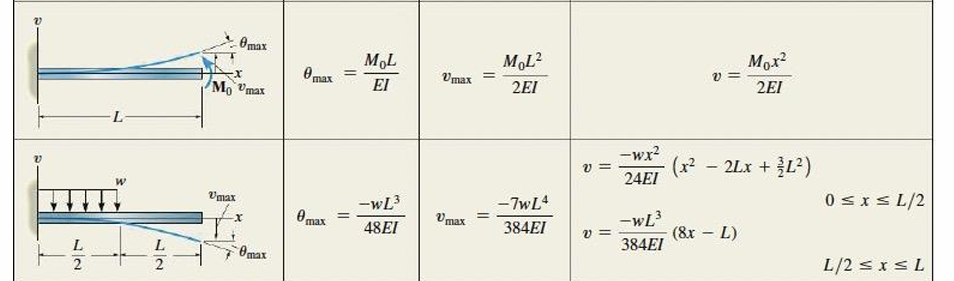

In [5]:
#HW11.9. Determine the reactions
from sympy import *

L = 6 # m
E = 236 # GPa
Iz = 0.000055 # m^4
w = 10 # kN/m

w=w*1000
l=L
e=E*1e9
iz=Iz

p , m = symbols('p,m')
y1=-7*w*l**4/384/e/iz
y2=p*l**3/3/e/iz
y3=m*l**2/2/e/iz

theta1=-w*l**3/48/e/iz
theta2=p*l**2/2/e/iz
theta3=m*l/e/iz

eq1=Eq(y1+y2+y3,0)
eq2=Eq(theta1+theta2+theta3,0)
sol = solve((eq1,eq2),(p,m))
print(sol)

{m: -9374.99999999974, p: 5624.99999999993}


In [6]:
#HW11.9. Determine the reactions
L = 6    # m
w = 11    # kN/m

# 直接用解析公式计算（E和Iz不影响反力大小）
Rc_magnitude = 3 * w * L / 32
Mc_magnitude = 5 * w * L**2 / 192

print(f"C端反力大小 |Rc| = {Rc_magnitude} kN")
print(f"C端反弯矩大小 |Mc| = {Mc_magnitude} kN·m")

C端反力大小 |Rc| = 6.1875 kN
C端反弯矩大小 |Mc| = 10.3125 kN·m


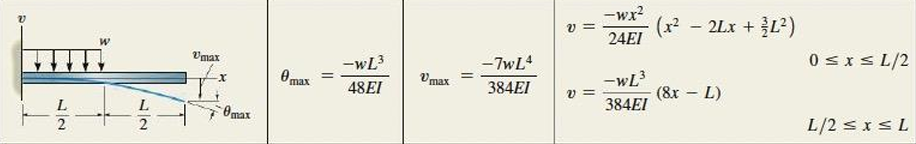
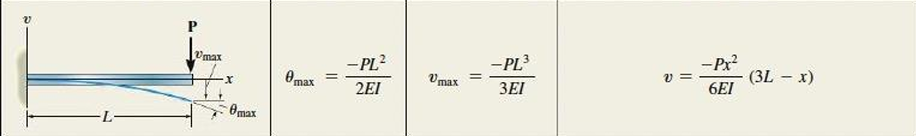
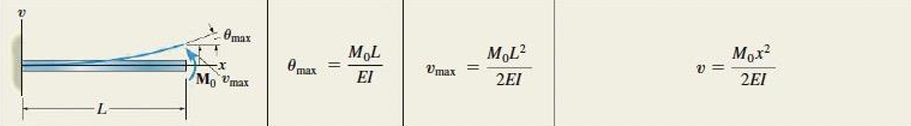

In [7]:
#HW11.10. Determine the reactions
from sympy import *

L = 6 # m
E = 247 # GPa
Iz = 0.000059 # m^4
w = 8 # kN/m

w=w*1000
l=L
e=E*1e9
iz=Iz

t = symbols('t')
v1=-5*w*l**4/384/e/iz
v2=t*l**3/48/e/iz
eq=Eq(v1+v2,0)
sol=solve(eq,t)
print(sol[0]/1e3)


30.0000000000000


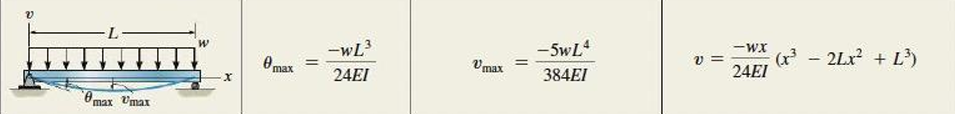
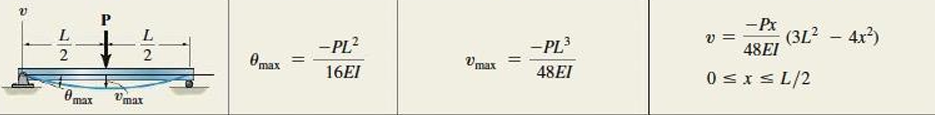